In [2]:
#  Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import warnings

In [3]:
df = pd.read_csv(r"/kaggle/input/datasets/codingloading/stock-trading-app-reviews-zerodha-groww-etc/Stock_Trading_App_Reviews.csv")

In [4]:
df.head()

,reviewId,content,score,app
0,be071c83-6d3c-4db3-94c0-2714c04fc47d,good app,4,Zerodha (Kite)
1,aedd0c3c-69ef-4088-813f-df473e00ef0f,good,5,Zerodha (Kite)
2,994812ae-8110-47e4-9e8f-6dba21dc37f8,nice app better than angelone in terms of brok...,5,Zerodha (Kite)
3,e15872b4-b646-4878-b35e-d26527379bec,good,5,Zerodha (Kite)
4,20237158-d654-4796-84c4-e809c7034de7,happy with customer service,5,Zerodha (Kite)


In [5]:
df.isnull().sum()

reviewId    0
content     2
score       0
app         0
dtype: int64

In [6]:
df.dropna(subset = ['content'],inplace = True)

In [7]:
df.isnull().sum()

reviewId    0
content     0
score       0
app         0
dtype: int64

In [8]:
df['sentiment'] = df['score'].apply(lambda x: 'positive' if x>=4 else ('negative' if x <=2 else'neutral'))

In [9]:
df.head()

,reviewId,content,score,app,sentiment
0,be071c83-6d3c-4db3-94c0-2714c04fc47d,good app,4,Zerodha (Kite),positive
1,aedd0c3c-69ef-4088-813f-df473e00ef0f,good,5,Zerodha (Kite),positive
2,994812ae-8110-47e4-9e8f-6dba21dc37f8,nice app better than angelone in terms of brok...,5,Zerodha (Kite),positive
3,e15872b4-b646-4878-b35e-d26527379bec,good,5,Zerodha (Kite),positive
4,20237158-d654-4796-84c4-e809c7034de7,happy with customer service,5,Zerodha (Kite),positive


/tmp/ipykernel_54/2140968406.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x = 'score',palette = "rocket")


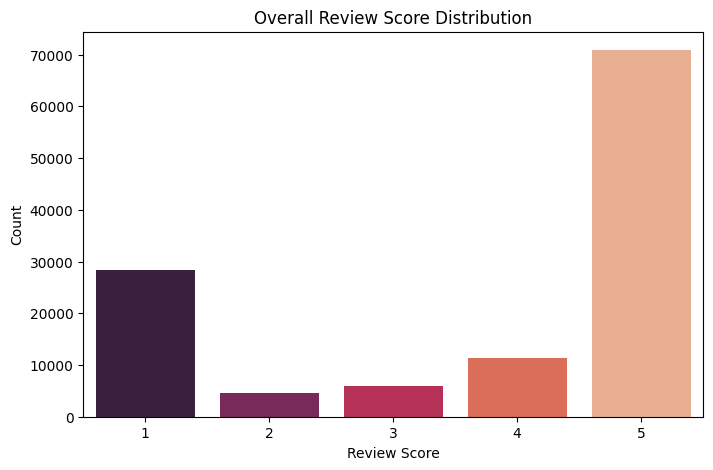

In [10]:
plt.figure(figsize = (8,5))
sns.countplot(data=df,x = 'score',palette = "rocket")
plt.title('Overall Review Score Distribution')
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

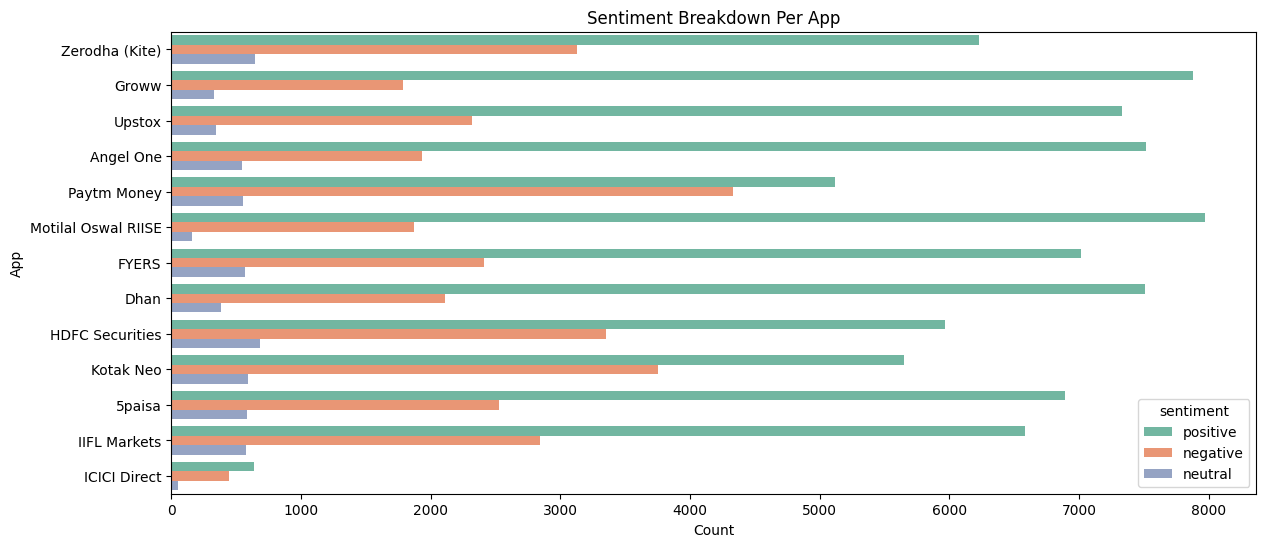

In [11]:
plt.figure(figsize=(14,6))
sns.countplot(data=df,y='app',hue = "sentiment",order=df['app'].value_counts().index,palette='Set2')
plt.title('Sentiment Breakdown Per App')
plt.xlabel('Count')
plt.ylabel('App')
plt.legend(title='sentiment')
plt.show()

/tmp/ipykernel_54/1872648088.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_score.values,y=avg_score.index,palette='coolwarm')


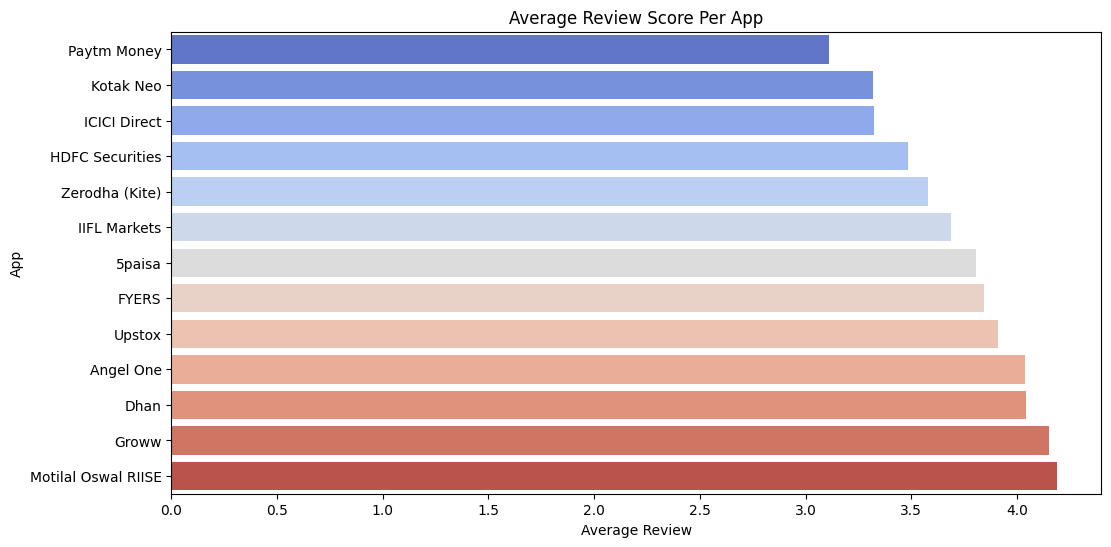

In [12]:
avg_score = df.groupby('app')['score'].mean().sort_values()
plt.figure(figsize=(12,6))
sns.barplot(x=avg_score.values,y=avg_score.index,palette='coolwarm')
plt.title('Average Review Score Per App')
plt.xlabel('Average Review')
plt.ylabel('App')
plt.show()

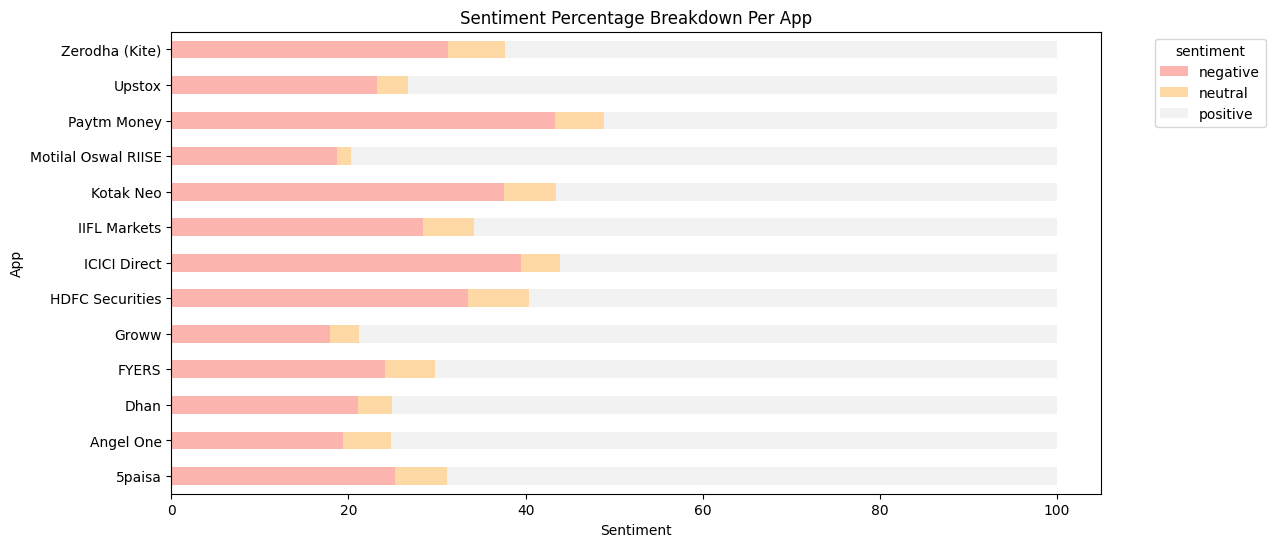

In [13]:
sentiment_ratio = df.groupby(['app','sentiment']).size().unstack().fillna(0)
sentiment_percent = sentiment_ratio.div(sentiment_ratio.sum(axis=1),axis=0)*100

sentiment_percent.plot(kind='barh',stacked=True,figsize=(12,6),colormap='Pastel1')
plt.title('Sentiment Percentage Breakdown Per App')
plt.xlabel('Sentiment')
plt.ylabel('App')
plt.legend(title='sentiment',bbox_to_anchor=(1.05,1),loc='upper left')
plt.show()

/tmp/ipykernel_54/1155808854.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='sentiment',palette='Set2')


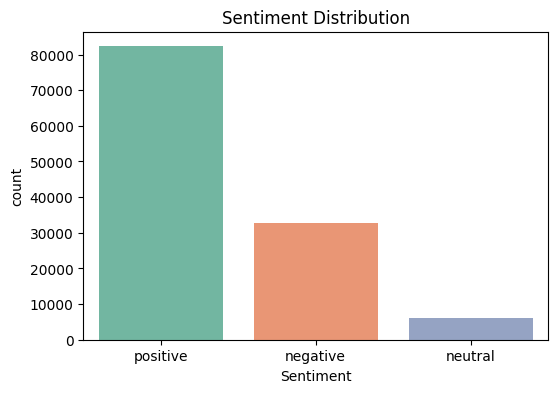

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='sentiment',palette='Set2')
plt.title("Sentiment Distribution")
plt.xlabel('Sentiment')
plt.show()

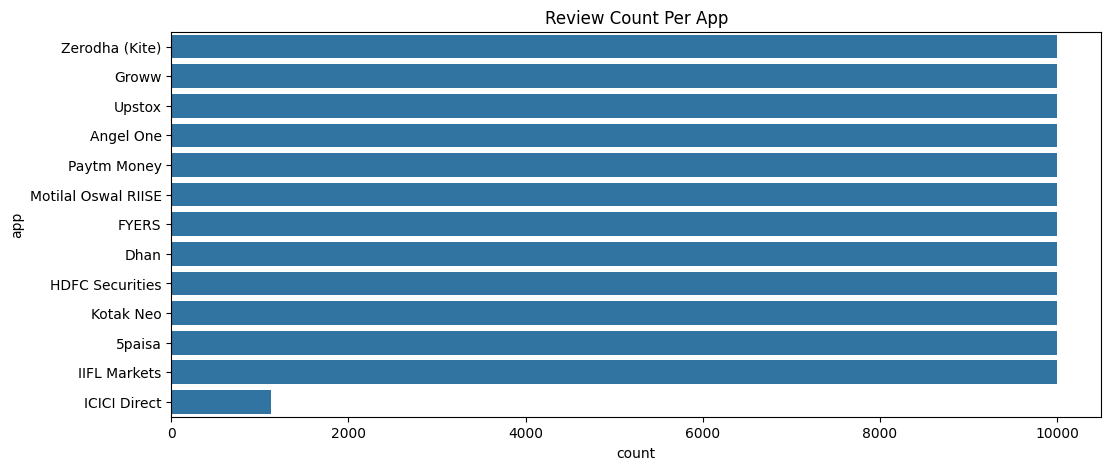

In [15]:
plt.figure(figsize=(12,5))
sns.countplot(data=df,y='app',order=df['app'].value_counts().index)
plt.title("Review Count Per App")
plt.show()

In [16]:
import wordcloud

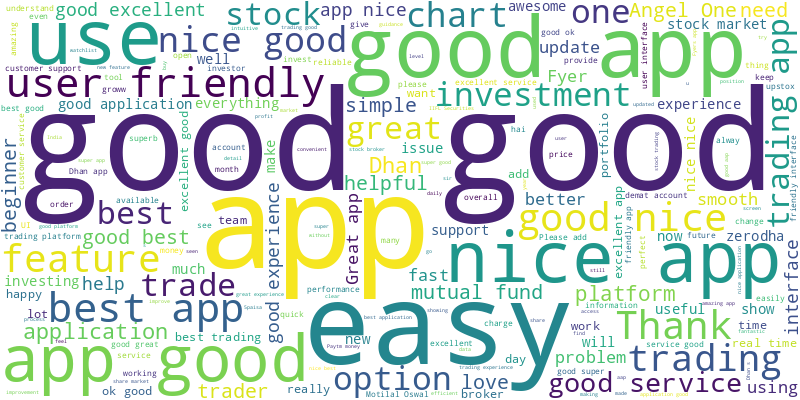

In [17]:
pos_text = " ".join(df[df.sentiment == 'positive']['content'].dropna())
WordCloud(width=800, height=400, background_color='white').generate(pos_text).to_image()

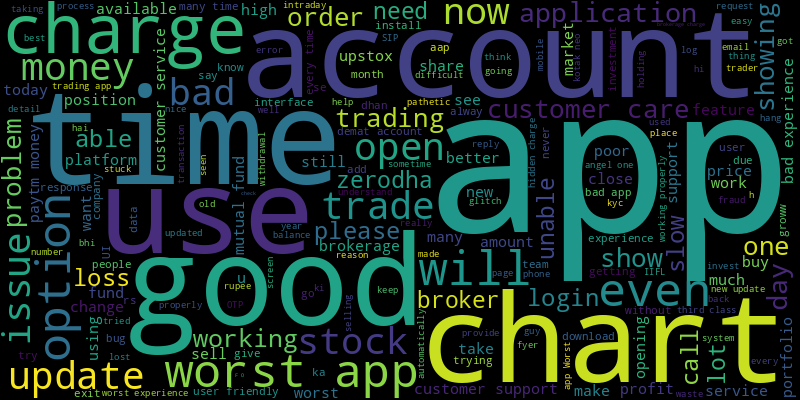

In [18]:
neg_text=" ".join(df[df.sentiment=='negative']['content'].dropna())
WordCloud(width=800,height=400,background_color='black').generate(neg_text).to_image()

In [19]:
df = df[df['sentiment'] != 'neutral']
x = df['content']
y = df['sentiment'].map({'positive':1,'negative':0})

In [20]:
vectorizer = TfidfVectorizer(stop_words='english',max_features=5000)
x_vec = vectorizer.fit_transform(x)

In [21]:
x_train,x_test,y_train,y_test = train_test_split(x_vec,y,test_size=0.2,random_state=42)

In [22]:
model = LogisticRegression()
model.fit(x_train,y_train)


LogisticRegression()

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.82      0.85      6546
           1       0.93      0.96      0.94     16476

    accuracy                           0.92     23022
   macro avg       0.91      0.89      0.90     23022
weighted avg       0.92      0.92      0.92     23022



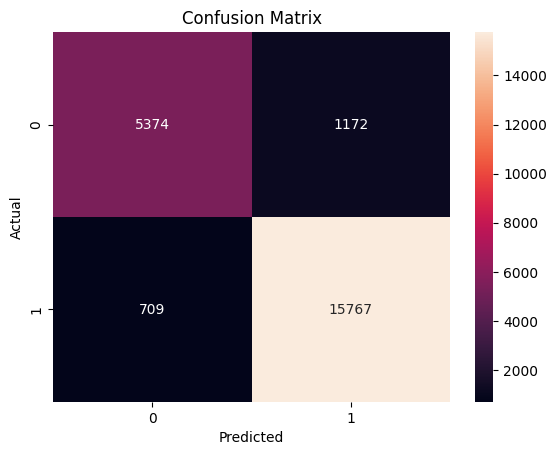

In [23]:
y_pred = model.predict(x_test)
print('Classification Report:\n' ,classification_report(y_test,y_pred))
sns.heatmap(confusion_matrix(y_test,y_pred),annot = True, fmt ='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Linear SVC:
               precision    recall  f1-score   support

           0       0.88      0.82      0.85      6546
           1       0.93      0.96      0.94     16476

    accuracy                           0.92     23022
   macro avg       0.90      0.89      0.89     23022
weighted avg       0.91      0.92      0.91     23022



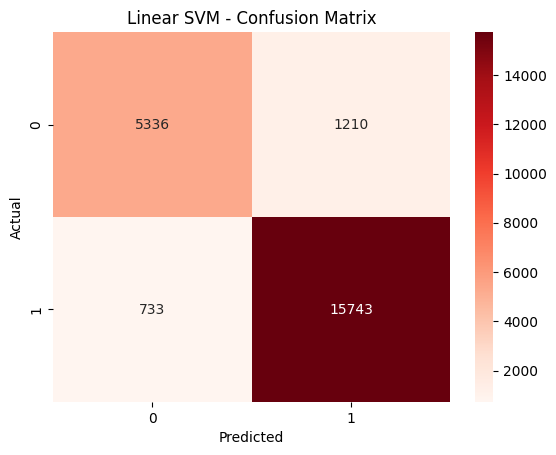

In [24]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(x_train,y_train)

y_pred = svm.predict(x_test)
print('Linear SVC:\n', classification_report(y_test,y_pred))
sns.heatmap(confusion_matrix(y_test,y_pred),annot = True, fmt ='d',cmap='Reds')
plt.title('Linear SVM - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:33:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 XGBoost
               precision    recall  f1-score   support

           0       0.90      0.76      0.82      6546
           1       0.91      0.96      0.94     16476

    accuracy                           0.91     23022
   macro avg       0.90      0.86      0.88     23022
weighted avg       0.91      0.91      0.90     23022



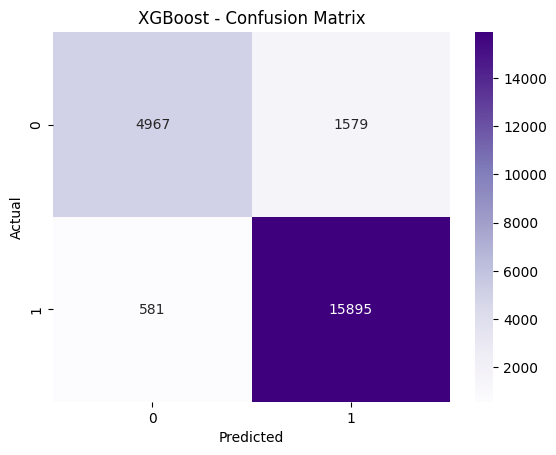

In [33]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)
print(" XGBoost\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest Classifier:
               precision    recall  f1-score   support

           0       0.85      0.84      0.85      6546
           1       0.94      0.94      0.94     16476

    accuracy                           0.91     23022
   macro avg       0.89      0.89      0.89     23022
weighted avg       0.91      0.91      0.91     23022



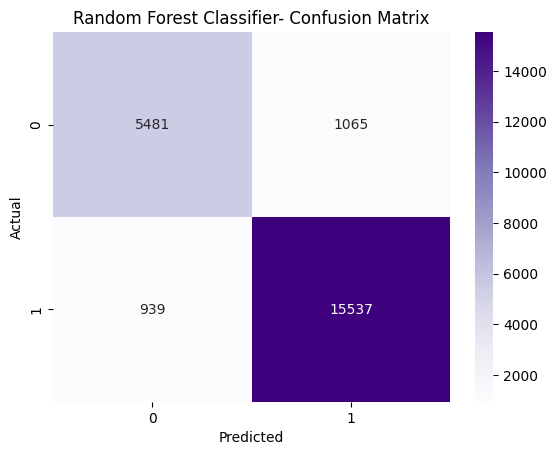

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 100 , random_state = 42)
rf.fit(x_train,y_train)

y_pred = rf.predict(x_test)
print('Random Forest Classifier:\n', classification_report(y_test,y_pred))
sns.heatmap(confusion_matrix(y_test,y_pred),annot = True, fmt ='d',cmap='Purples')
plt.title('Random Forest Classifier- Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
